In [22]:
from __future__ import annotations

import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

In [23]:
def load_report_data(data_dir: str, metric: str) -> tuple[pd.DataFrame, str]:
    """Load CSV report files from a model directory and return a tidy DataFrame and the model name."""
    data_path = Path(data_dir)
    csv_files = sorted(data_path.glob("*.csv"))

    model_name = ""
    rows: list[dict[str, object]] = []
    for csv_file in csv_files:
        stem = csv_file.stem  # e.g. 2026-02-28-report-imc-2d-gpt5mini-baseline
        # Strip date prefix: remove everything before and including "-report-"
        middle = stem.split("-report-", 1)[1]  # e.g. imc-2d-gpt5mini-baseline
        # condition is always the last hyphen-separated token
        condition = middle.rsplit("-", 1)[1]  # e.g. baseline
        remainder = middle.rsplit("-", 1)[0]  # e.g. imc-2d-gpt5mini
        # model is the last token of the remainder
        model = remainder.rsplit("-", 1)[1]  # e.g. gpt5mini
        assay = remainder.rsplit("-", 1)[0]  # e.g. imc-2d

        if not model_name:
            model_name = model

        df = pd.read_csv(csv_file)
        for val in df[metric]:
            rows.append({"assay": assay, "condition": condition, "metric_value": val})

    result = pd.DataFrame(rows)

    # Compute summary stats per assay per condition
    stats = result.groupby(["assay", "condition"])["metric_value"].agg(["mean", "min", "max"]).reset_index()
    result = result.merge(stats, on=["assay", "condition"])
    return result, model_name

In [28]:
import csv
from typing import Any


def write_csv(metrics: list[dict[str, Any]], fieldnames: list[str], report_path: Path) -> None:
    """Write a CSV table."""
    report_path.parent.mkdir(parents=True, exist_ok=True)

    with open(report_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in metrics:
            writer.writerow(row)

In [68]:
from typing import Any

from metrics import (
    compute_ontology_constrained_field_accuracy,
    compute_non_ontology_constrained_field_accuracy,
    compute_overall_accuracy,
)


def apply_metrics(input_dir: Path, gold_dir: Path, schema_path: str) -> list[dict[str, Any]]:
    """Compare predicted outputs in *input_dir* against gold standards in *gold_dir*."""
    input_files = sorted(input_dir.glob("*.json"))
    results: list[dict[str, Any]] = []

    for input_file in input_files:
        gold_file = gold_dir / input_file.name
        if not gold_file.exists():
            continue

        with open(input_file) as f:
            predicted = json.load(f)
        with open(gold_file) as f:
            gold = json.load(f)

        results.append(
            {
                "input_file": input_file.name,
                "ontology_constrained_fields_accuracy": compute_ontology_constrained_field_accuracy(
                    predicted, gold, schema_path
                ),
                "non_ontology_constrained_fields_accuracy": compute_non_ontology_constrained_field_accuracy(
                    predicted, gold, schema_path
                ),
                "overall_accuracy": compute_overall_accuracy(predicted, gold),
            }
        )

    return results

In [ ]:
ASSAY_LIST = [
    "af",
    "atacseq",
    "celldive",
    "codex",
    "desi",
    "histology",
    "imc-2d",
    "lcms",
    "lightsheet",
    "maldi",
    "mibi",
    "rnaseq",
]
PREFIX = "2026-03-02"
MODEL = "gpt41mini"
INPUT_TYPE = "experiment" # baseline
OUTPUT_TYPE = "experiment" # baseline | sowmya
OUTPUT_DIR = "report/prediction-accuracy"

for assay in ASSAY_LIST:
    result = apply_metrics(
        Path(f"../data/{assay}/output/{MODEL}/{INPUT_TYPE}"), Path(f"../data/{assay}/gold"), f"../data/schemas/{assay}.json"
    )
    write_csv(
        result,
        [
            "input_file",
            "ontology_constrained_fields_accuracy",
            "non_ontology_constrained_fields_accuracy",
            "overall_accuracy",
        ],
        Path(f"{OUTPUT_DIR}/{MODEL}/{PREFIX}-report-{assay}-{MODEL}-{OUTPUT_TYPE}.csv"),
    )
print("Done.")

Done.


In [63]:
ASSAY_ORDER = [
    ("rnaseq", "RNAseq"),
    ("atacseq", "ATACseq"),
    ("af", "Auto-fluorescence"),
    ("codex", "CODEX"),
    ("mibi", "MIBI"),
    ("histology", "Histology"),
    ("celldive", "Cell DIVE"),
    ("imc-2d", "IMC-2D"),
    ("lightsheet", "Lightsheet"),
    ("lcms", "LC-MS"),
    ("maldi", "MALDI"),
    ("desi", "DESI"),
]


def plot_grouped_bar_chart(data_dir: str, metric: str, title: str) -> None:
    """Grouped bar chart with mean height and min-max error bars."""
    df, model_name = load_report_data(data_dir, metric)

    stats = df.groupby(["assay", "condition"])["metric_value"].agg(["mean", "min", "max"]).reset_index()
    available = set(stats["assay"].unique())
    ordered = [(k, lbl) for k, lbl in ASSAY_ORDER if k in available]
    assays = [k for k, _ in ordered]
    assay_labels = [lbl for _, lbl in ordered]
    x = np.arange(len(assays))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 4))
    for i, (condition, color) in enumerate([("baseline", "#4472C4"), ("experiment", "#ED7D31")]):
        cond_stats = stats[stats["condition"] == condition].set_index("assay").reindex(assays)
        means = cond_stats["mean"].values
        err_low = means - cond_stats["min"].values
        err_high = cond_stats["max"].values - means
        ax.bar(
            x + (i - 0.5) * width,
            means,
            width,
            yerr=[err_low, err_high],
            capsize=3,
            color=color,
            label=condition.capitalize(),
        )

    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel(metric.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(assay_labels, rotation=45, ha="right")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2)
    fig.tight_layout()
    plt.show()

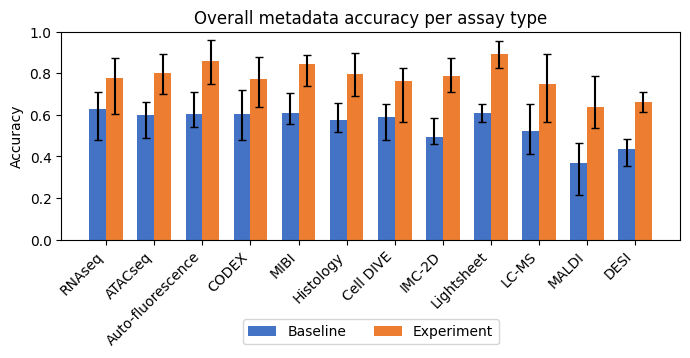

In [ ]:
# Record accuracy - Baseline with System Prompt
# plot_grouped_bar_chart("report/record-accuracy-baseline-non-orig/gpt41mini", "accuracy")
plot_grouped_bar_chart("report/record-accuracy-baseline-non-orig/gpt5mini", "overall_accuracy", "Overall metadata accuracy per assay type")

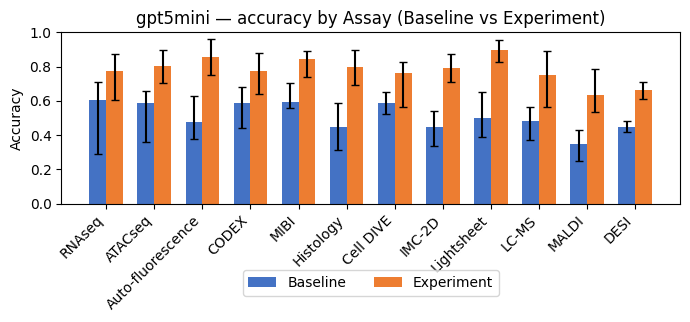

In [ ]:
# Record accuracy - Baseline without System Prompt
# plot_grouped_bar_chart("report/record-accuracy-baseline-orig/gpt41mini", "accuracy")
plot_grouped_bar_chart("report/record-accuracy-baseline-orig/gpt5mini", "accuracy")